Statistical Inference & Linear Regression

In [165]:
import pandas as pd
import numpy as np  

In [166]:
df = pd.read_csv("cleaned_diabetes.csv")
df

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_Binary
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0,0.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0,0.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0,0.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0,0.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
229776,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,...,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0,0.0
229777,2.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0,1.0
229778,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0,0.0
229779,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,...,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0,0.0


Hypotheses for t-tests

H0: The mean BMI is the same for diabetics and non-diabetics.

H1: The mean BMI is different for diabetics and non-diabetics.


H0: The mean BMI is the same for females and males.

H1: The mean BMI is different for females and males



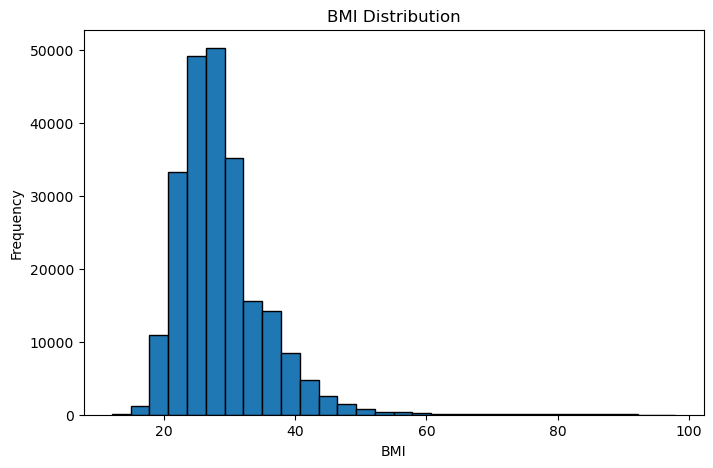

In [167]:
# Check whether the BMI(Numerical variablel) follow a normal distribution
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(df['BMI'], bins=30, edgecolor='black')
plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()

BMI is  slightly skewed to the Right, so the data is not perfectly normally distributed. However we can still perform a t-test as we have large sample size.

In [168]:
from scipy.stats import ttest_ind
df_diabetic  = df.loc[df['Diabetes_Binary'] ==1]
df_non_diabetic = df.loc[df['Diabetes_Binary']==0]

ttest_ind(df_diabetic['BMI'],df_non_diabetic['BMI'])


TtestResult(statistic=np.float64(103.55268543477045), pvalue=np.float64(0.0), df=np.float64(229779.0))

Comparing the mean BMI between diabetics/prediabetics and non-diabetics resulted in a statistically significant difference in mean BMI between the two groups, t= 103.55, p < 0.001. Therefore, reject the null hypotheses.

In [169]:
df.groupby(['Sex'])['BMI'].mean()

Sex
0.0    28.499550
1.0    28.923291
Name: BMI, dtype: float64

In [170]:
df_male = df.loc[df['Sex']==1]
df_female = df.loc[df['Sex']==0]

ttest_ind(df_male['BMI'],df_female['BMI'])


TtestResult(statistic=np.float64(14.861650653035822), pvalue=np.float64(6.168113157019289e-50), df=np.float64(229779.0))

The t-test showed a statistically significant difference in mean BMI between males and females, t(229,779) = 14.86, p < 0.001. Since the p-value is smaller than the significance level of 0.05, the null hypothesis was rejected. However, the difference in mean BMI between the two groups was relatively small, with females having a mean BMI of 28.50 and males having a mean BMI of 28.92. This result demonstrates that with a very large sample size, even small differences can become statistically significant.

Hypotheses for chi-square tests 

H0: There is no association between sex and diabetes status.

H1: There is an association between sex and diabetes status

H0: There is no association between physical activity and diabetes status.

H1: There is an association between physical activity and diabetes status.


In [171]:
table = pd.crosstab(index=df['Sex'], columns=df['Diabetes_Binary'],margins=True)
table

Diabetes_Binary,0.0,1.0,All
Sex,,,
0.0,107905,20949,128854
1.0,82150,18777,100927
All,190055,39726,229781


In [172]:
chi2, p, dof, ex = chi2_contingency(table)

print("chi2 = ", chi2)
print("p = ", p)
print("degrees of freedom = ", dof)
print("expected = ", ex)


chi2 =  217.94334209517282
p =  5.193802182966211e-46
degrees of freedom =  4
expected =  [[106576.9013539  22277.0986461 128854.       ]
 [ 83478.0986461  17448.9013539 100927.       ]
 [190055.         39726.        229781.       ]]


The chi-square test of independence examined whether diabetes status is associated with sex. The results indicated a statistically significant association between sex and diabetes status as the P-value < 0.001 we conclude to reject the null hypothesis

In [173]:
table = pd.crosstab(index=df['PhysActivity'], columns=df['Diabetes_Binary'],margins=True)
table

Diabetes_Binary,0.0,1.0,All
PhysActivity,,,
0.0,46743,14527,61270
1.0,143312,25199,168511
All,190055,39726,229781


In [174]:
chi2, p, dof, ex = chi2_contingency(table)

print("chi2 = ", chi2)
print("p = ", p)
print("degrees of freedom = ", dof)
print("expected = ", ex)


chi2 =  2408.999001351394
p =  0.0
degrees of freedom =  4
expected =  [[ 50677.25290603  10592.74709397  61270.        ]
 [139377.74709397  29133.25290603 168511.        ]
 [190055.          39726.         229781.        ]]


The results above showed a statistically significant association between physical activity and diabetes status chi2 =  2408.9990, P-value < 0. We reject the null hypothesis and conclude that diabetes status differs significantly across physical activity categories.


Hypotheses for linear regression test

H0: There is no relationship between the number of poor physical health days and BMI
H1: There is a relationship between the number of poor physical health days and BMI

H0: There is no relationship between the number of poor mental health days and BMI.
H1: There is  a relationship between the number of poor mental health days and BMI.


o Dependent variable = BMI
o Independent variable = PhysHlth and MentHlth
o Control variables =  Education, Sex / Age, Income


Create a scatterplot by using the dependent and the independent

<Axes: xlabel='PhysHlth', ylabel='BMI'>

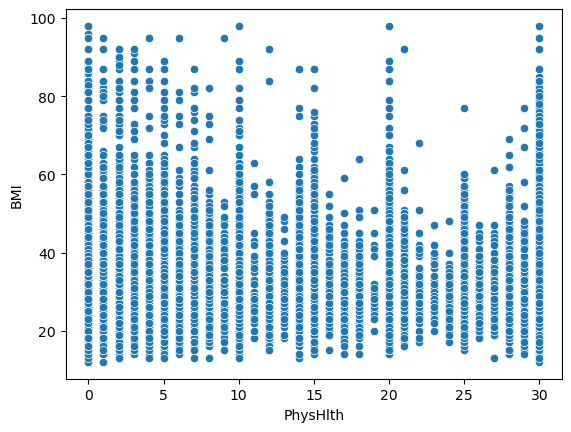

In [175]:
import seaborn as sns
sns.scatterplot(data=df,
                x='PhysHlth', 
                y='BMI')

For the scatterplot above, we use BMI for our dependent variable (BMI is a numerical continuos variable) and PhysHlt(which countss on a scale from 1-30 days where r physical health was not good) as independent variable. There is no clear linear relationship between the two variables. It is not evident whether there is a positive or negative linear relationship. Since `PhysHlth` is an ordinal variable, the points are grouped in vertical columns. This makes it difficult to see a clear linear pattern. However, we can still observe major concentration of observations on opposite sides, with 0 for good physical health and 30 for poor health throughout the month.

<Axes: xlabel='MentHlth', ylabel='BMI'>

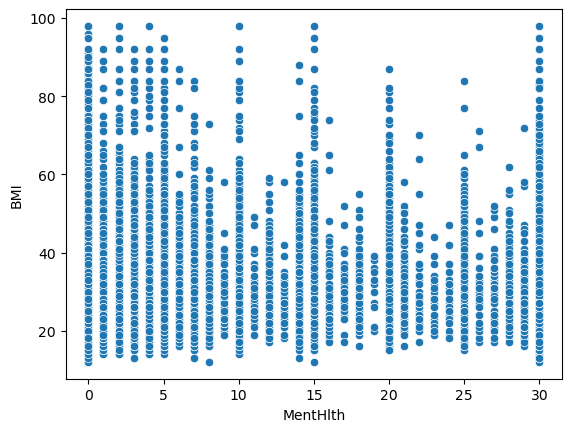

In [176]:
sns.scatterplot(data=df,
                x='MentHlth', 
                y='BMI')

In the second scatterplot, we use BMI for our dependent variable again, and MenHlt(which countss on a scale from 1-30 days where mental health was not good) as independent variable.Here we encountered the same situation as the previos scatterplot since `MenHlth` is an ordinal variable, the points are grouped in vertical columns.There is no clear linear relationship between the two variables.In addition, there is a concentrtion of observations on the 0 and 30.

In [177]:
import pingouin as pg

mod1 = pg.linear_regression(
    X=df[['MentHlth', 'Age', 'Income']],
    y=df['BMI']
)
mod1

,names,coef,se,T,pval,r2,adj_r2,CI2.5,CI97.5
0,Intercept,30.699905,0.062362,492.289375,0.000000e+00,0.010603,0.01059,30.577678,30.822132
1,MentHlth,0.044946,0.001873,23.991258,4.923187e-127,0.010603,0.01059,0.041275,0.048618
2,Age,-0.113375,0.004621,-24.535848,9.090770e-133,0.010603,0.01059,-0.122432,-0.104319
3,Income,-0.213054,0.006916,-30.806031,5.792846e-208,0.010603,0.01059,-0.226609,-0.199499


Mental health coefficeient tell us that for every additional day of poor mental health, BMI is predicted to increase by 0.04 units, keeping age and income constant. Since P-value is less than 0.01, this relationship is statistically significant. Suggesting that mental health is a good predictor for BMI. 

Age coefficient -0.11 is associated with a 0.11 decrease in BMI when holding all other variables constant. Age has a negative and statistically significant association with BMI as P value < 0.001. Similarly, Income coefficient is associated with a 0.21 decrease in BMI. It also has a negative significant association with BM

The model has a R2 of 0.011, meaning that 1.1% of the variation BMI is explained by poor mental health, Age and Income. Despite statistically significant, the model explains only a tiny portion of the variability in BMI, suggesting that other factors not included in the model influence BMI.

In [178]:
mod1 = pg.linear_regression(
    X=df[['PhysHlth', 'Education', 'Sex']],
    y=df['BMI']
)
mod1

,names,coef,se,T,pval,r2,adj_r2,CI2.5,CI97.5
0,Intercept,30.267821,0.074664,405.387264,0.000000e+00,0.015725,0.015713,30.121482,30.414161
1,PhysHlth,0.072331,0.001567,46.161707,0.000000e+00,0.015725,0.015713,0.069260,0.075402
2,Education,-0.429341,0.014264,-30.099012,1.218721e-198,0.015725,0.015713,-0.457299,-0.401383
3,Sex,0.496438,0.028331,17.522915,1.061975e-68,0.015725,0.015713,0.440910,0.551965


The coefficient for physHlth is 0.072, indicating that each additional day of poor physical health is associated wiith a 0.072 units increase in BMI having education and sex as control variables. P-value < 0.001 indicating this relation is statistically significant. Moreover, we reject the null hypothesis.


The coefficient for education is -0.43, the relationship is negative suggesting that individuals with higher education levels tend to have lower BMI. P-value <0.05 then Education is a statistically significant predictor of BMI.
The Sex coeeficient is 0.50 meaning that males have a mean BMI that is about 0.50 units higher than females.P-value <0.05 then Sex is a statistically significant predictor of BMI.

R2 is 0.0157, indicating that the model explains about 1.6% of the variation BMI, it is a very low percentage so we conclude that there are many other factors influencing BMI. Even though it is statistically significant, this is not a good predictive model for BMI.